### Sequential WorkFlow

In [9]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_cohere import ChatCohere
from dotenv import load_dotenv
load_dotenv()

True

#### Define Model

In [10]:
model = ChatCohere(model="command-a-03-2025")

#### Define State

In [11]:
class AskMeState(TypedDict):
    question: str
    answer: str

#### Define Node Function

In [12]:
def ask_me(state: AskMeState) -> AskMeState:
    question = state["question"]
    response = model.invoke(question)
    state["answer"] = response.content
    return state

#### Create Graph

In [13]:
graph = StateGraph(AskMeState)

### Add Nodes to the graph

In [14]:
graph.add_node('ask_me', ask_me)

#### Add Edges to the graph

In [15]:
graph.add_edge(START, 'ask_me')
graph.add_edge('ask_me', END)

#### Compile  graph

In [16]:
workflow = graph.compile()

#### Show Graph

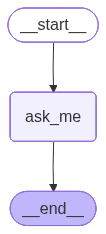

In [17]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

#### Execute Graph

In [19]:
input_state = {
    'question': "What is the capital of France?"
}

output_state = workflow.invoke(input_state)

#### Final State

In [20]:
print(output_state)

{'question': 'What is the capital of France?', 'answer': "The capital of France is **Paris**. It is the country's largest city and main cultural, commercial, and administrative center. Paris is known for its iconic landmarks such as the Eiffel Tower, the Louvre Museum, Notre-Dame Cathedral, and the Champs-Élysées."}
